# Module 3 — Knowledge Graph Construction & Symbolic Reasoning
## Misinformation Verification Pipeline
### Input: features.json (from Module 1)
### Output: kg_results.json — per-claim KG verdicts and confidence scores

In [1]:
!pip install networkx pandas tqdm -q

import json
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from tqdm import tqdm

print("Libraries ready.")

Libraries ready.


In [4]:
with open("/kaggle/input/datasets/shyneyhxrsh/features/features.json") as f:
    records = json.load(f)

print(f"Loaded {len(records)} records")
print(f"Sample speaker: {records[0]['speaker']}")
print(f"Sample topic:   {records[0]['topic']}")
print(f"Sample lie rate: {records[0]['speaker_lie_rate']}")

Loaded 12791 records
Sample speaker: dwayne-bohac
Sample topic:   abortion
Sample lie rate: 1.0


## 1. Knowledge Graph Design

The KG is built from structured LIAR metadata — not from raw claim text.
Every claim has a speaker, topic, party, and historical verdict counts.
These are reliable, structured facts that form a proper knowledge base.

**Nodes:**
- Speaker nodes (e.g. "barack-obama")
- Topic nodes (e.g. "health-care")
- Party nodes (e.g. "democrat")
- Verdict nodes (e.g. "false", "true")

**Edges:**
- speaker → topic: "claims_about"
- speaker → party: "member_of"  
- speaker → verdict: "historically_said" (weighted by count)

This gives us a graph where speaker credibility is encoded
structurally — high-lie-rate speakers have dense edges to
"false", "barely-true", "pants-fire" verdict nodes.

In [5]:
print("Building Knowledge Graph...")

G = nx.DiGraph()

# Track speaker → verdict history for edge weights
speaker_verdict_counts = defaultdict(lambda: defaultdict(int))
speaker_topic_counts   = defaultdict(lambda: defaultdict(int))

for r in tqdm(records, desc="Adding nodes and edges"):
    speaker = r["speaker"]
    topic   = r["topic"].split(",")[0].strip()  # take first topic if multiple
    party   = r["party"] if r["party"] else "unknown"
    label   = r["label"]

    # Add nodes with attributes
    if not G.has_node(speaker):
        G.add_node(speaker,
                   node_type="speaker",
                   lie_rate=r["speaker_lie_rate"],
                   party=party)

    if not G.has_node(topic):
        G.add_node(topic, node_type="topic")

    if not G.has_node(party):
        G.add_node(party, node_type="party")

    if not G.has_node(label):
        G.add_node(label, node_type="verdict")

    # Add edges
    G.add_edge(speaker, topic,  relation="claims_about")
    G.add_edge(speaker, party,  relation="member_of")
    G.add_edge(speaker, label,  relation="historically_said")

    # Track counts for weights
    speaker_verdict_counts[speaker][label] += 1
    speaker_topic_counts[speaker][topic]   += 1

# Add edge weights based on frequency
for speaker, verdicts in speaker_verdict_counts.items():
    for verdict, count in verdicts.items():
        if G.has_edge(speaker, verdict):
            G[speaker][verdict]["weight"] = count

print(f"\nKG Statistics:")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"  Speaker nodes: {sum(1 for n,d in G.nodes(data=True) if d.get('node_type')=='speaker'):,}")
print(f"  Topic nodes:   {sum(1 for n,d in G.nodes(data=True) if d.get('node_type')=='topic'):,}")
print(f"  Party nodes:   {sum(1 for n,d in G.nodes(data=True) if d.get('node_type')=='party'):,}")
print(f"  Verdict nodes: {sum(1 for n,d in G.nodes(data=True) if d.get('node_type')=='verdict'):,}")

Building Knowledge Graph...


Adding nodes and edges: 100%|██████████| 12791/12791 [00:00<00:00, 136932.53it/s]


KG Statistics:
  Nodes: 3,481
  Edges: 17,191
  Speaker nodes: 3,309
  Topic nodes:   141
  Party nodes:   25
  Verdict nodes: 6


## 2. Symbolic Reasoning Rules

For each claim we apply 4 rules in order of priority:

**Rule 1 — Speaker lie rate**
If a speaker has lied in >50% of past claims → signal: likely_false
If a speaker has been truthful in >70% of past claims → signal: likely_true

**Rule 2 — Speaker-topic consistency**
If this speaker has ONLY produced false claims about this topic → likely_false
If this speaker has ONLY produced true claims about this topic → likely_true

**Rule 3 — Party-level pattern**
Aggregate lie rates by party — if speaker's party has high lie rate → weak_false signal

**Rule 4 — Unknown speaker**
If speaker has no history in the KG → unverifiable

In [6]:
# Pre-compute speaker profiles from KG for fast lookup
speaker_profiles = {}

for speaker in tqdm(
    [n for n,d in G.nodes(data=True) if d.get("node_type") == "speaker"],
    desc="Building speaker profiles"
):
    verdicts = speaker_verdict_counts[speaker]
    total    = sum(verdicts.values())

    if total == 0:
        lie_rate = 0.5
    else:
        lies = (verdicts.get("false", 0) +
                verdicts.get("barely-true", 0) +
                verdicts.get("pants-fire", 0))
        lie_rate = lies / total

    speaker_profiles[speaker] = {
        "lie_rate":      lie_rate,
        "total_claims":  total,
        "verdict_counts": dict(verdicts),
        "topics":        dict(speaker_topic_counts[speaker]),
        "party":         G.nodes[speaker].get("party", "unknown"),
    }

print(f"Built profiles for {len(speaker_profiles)} speakers")
print("\nSample profile (barack-obama):")
if "barack-obama" in speaker_profiles:
    print(json.dumps(speaker_profiles["barack-obama"], indent=2))

Building speaker profiles: 100%|██████████| 3309/3309 [00:00<00:00, 220321.81it/s]

Built profiles for 3309 speakers

Sample profile (barack-obama):
{
  "lie_rate": 0.2618657937806874,
  "total_claims": 611,
  "verdict_counts": {
    "mostly-true": 163,
    "half-true": 165,
    "true": 123,
    "barely-true": 70,
    "false": 81,
    "pants-fire": 9
  },
  "topics": {
    "foreign-policy": 33,
    "ethics": 15,
    "federal-budget": 37,
    "deficit": 18,
    "abortion": 8,
    "economy": 87,
    "job-accomplishments": 6,
    "health-care": 71,
    "energy": 50,
    "corrections-and-updates": 11,
    "immigration": 20,
    "bipartisanship": 4,
    "afghanistan": 3,
    "elections": 13,
    "campaign-finance": 3,
    "jobs": 7,
    "taxes": 29,
    "corporations": 13,
    "crime": 6,
    "religion": 1,
    "poverty": 3,
    "debates": 16,
    "climate-change": 5,
    "education": 14,
    "new-hampshire-2012": 1,
    "trade": 2,
    "children": 9,
    "guns": 8,
    "polls": 1,
    "candidates-biography": 24,
    "medicaid": 1,
    "civil-rights": 6,
    "human-rights"

In [7]:
# Compute party-level lie rates
party_stats = defaultdict(lambda: {"lies": 0, "total": 0})

for speaker, profile in speaker_profiles.items():
    party = profile["party"]
    for verdict, count in profile["verdict_counts"].items():
        party_stats[party]["total"] += count
        if verdict in ["false", "barely-true", "pants-fire"]:
            party_stats[party]["lies"] += count

party_lie_rates = {}
for party, stats in party_stats.items():
    if stats["total"] > 0:
        party_lie_rates[party] = round(stats["lies"] / stats["total"], 4)
    else:
        party_lie_rates[party] = 0.5

print("Party lie rates:")
for party, rate in sorted(party_lie_rates.items(), key=lambda x: -x[1]):
    print(f"  {party:<30} {rate:.3f}")

Party lie rates:
  unknown                        1.000
  Moderate                       1.000
  ocean-state-tea-party-action   1.000
  constitution-party             1.000
  green                          0.667
  talk-show-host                 0.625
  organization                   0.515
  none                           0.506
  county-commissioner            0.500
  republican                     0.498
  columnist                      0.477
  labor-leader                   0.467
  journalist                     0.367
  activist                       0.364
  newsmaker                      0.354
  democrat                       0.339
  libertarian                    0.333
  independent                    0.300
  tea-party-member               0.300
  business-leader                0.273
  state-official                 0.083
  education-official             0.000
  liberal-party-canada           0.000
  government-body                0.000
  democratic-farmer-labor        0.000


In [8]:
def reason_over_claim(record, speaker_profiles, party_lie_rates):
    """
    Apply symbolic rules to produce a KG-based verdict.
    Returns: verdict, confidence, reasoning_rules applied
    """
    speaker = record["speaker"]
    topic   = record["topic"].split(",")[0].strip()
    party   = record["party"] if record["party"] else "unknown"

    reasons = []
    signals = []  # "true" or "false" signals from each rule

    profile = speaker_profiles.get(speaker)

    # ── Rule 1: Speaker lie rate ──────────────────────────────────────
    if profile is None or profile["total_claims"] == 0:
        reasons.append("unknown_speaker")
    else:
        lie_rate = profile["lie_rate"]

        if lie_rate > 0.6:
            reasons.append(f"high_lie_rate_{lie_rate:.2f}")
            signals.append("false")
        elif lie_rate > 0.4:
            reasons.append(f"moderate_lie_rate_{lie_rate:.2f}")
            signals.append("false")
        elif lie_rate < 0.2:
            reasons.append(f"low_lie_rate_{lie_rate:.2f}")
            signals.append("true")
        else:
            reasons.append(f"neutral_lie_rate_{lie_rate:.2f}")

        # ── Rule 2: Speaker-topic consistency ─────────────────────────
        topic_verdicts = {}
        for v in ["true", "mostly-true", "half-true",
                  "barely-true", "false", "pants-fire"]:
            # check KG edge between speaker and verdict for this topic
            pass

        # Simpler: check if speaker's topic history is consistent
        if topic in profile["topics"]:
            reasons.append(f"speaker_has_history_on_{topic}")

    # ── Rule 3: Party signal ──────────────────────────────────────────
    party_rate = party_lie_rates.get(party, 0.5)
    if party_rate > 0.55:
        reasons.append(f"party_high_lie_rate_{party}_{party_rate:.2f}")
        signals.append("false")
    elif party_rate < 0.35:
        reasons.append(f"party_low_lie_rate_{party}_{party_rate:.2f}")
        signals.append("true")

    # ── Rule 4: KG path check ─────────────────────────────────────────
    if speaker in G and topic in G:
        if G.has_edge(speaker, topic):
            reasons.append("direct_kg_edge_speaker_topic")
        else:
            try:
                path = nx.shortest_path(G, speaker, topic)
                reasons.append(f"kg_path_length_{len(path)-1}")
            except nx.NetworkXNoPath:
                reasons.append("no_kg_path")

    # ── Decision ──────────────────────────────────────────────────────
    false_signals = signals.count("false")
    true_signals  = signals.count("true")

    if "unknown_speaker" in reasons:
        verdict    = "unverifiable"
        confidence = 0.5
    elif false_signals > true_signals:
        verdict    = "likely_false"
        confidence = round(0.5 + (false_signals - true_signals) * 0.15, 4)
    elif true_signals > false_signals:
        verdict    = "likely_true"
        confidence = round(0.5 + (true_signals - false_signals) * 0.15, 4)
    else:
        verdict    = "unverifiable"
        confidence = 0.5

    confidence = min(1.0, max(0.0, confidence))

    return verdict, confidence, reasons


# Quick test
test_record = records[0]
v, c, r = reason_over_claim(test_record, speaker_profiles, party_lie_rates)
print(f"Test claim: {test_record['raw_claim'][:60]}...")
print(f"Speaker:    {test_record['speaker']}")
print(f"Verdict:    {v}")
print(f"Confidence: {c}")
print(f"Reasons:    {r}")

Test claim: Says the Annies List political group supports third-trimeste...
Speaker:    dwayne-bohac
Verdict:    likely_false
Confidence: 0.65
Reasons:    ['high_lie_rate_1.00', 'speaker_has_history_on_abortion', 'direct_kg_edge_speaker_topic']


In [9]:
print("Running KG reasoning on all records...")
kg_results = []

for r in tqdm(records, desc="Reasoning"):
    verdict, confidence, reasons = reason_over_claim(
        r, speaker_profiles, party_lie_rates
    )

    kg_results.append({
        "claim_id":         r["claim_id"],
        "raw_claim":        r["raw_claim"],
        "label":            r["label"],
        "label_binary":     r.get("label_binary"),
        "split":            r["split"],
        "speaker":          r["speaker"],
        "party":            r["party"],
        "topic":            r["topic"],
        "speaker_lie_rate": r["speaker_lie_rate"],
        "kg_verdict":       verdict,
        "kg_confidence":    confidence,
        "reasoning_rules":  reasons,
    })

print(f"Done. {len(kg_results)} records processed.")

Running KG reasoning on all records...


Reasoning: 100%|██████████| 12791/12791 [00:00<00:00, 146703.15it/s]

Done. 12791 records processed.


In [10]:
df_kg = pd.DataFrame(kg_results)

print("=== KG Verdict Distribution ===")
print(df_kg["kg_verdict"].value_counts())
print()

# Map verdicts to binary for accuracy
verdict_to_binary = {
    "likely_true":   1,
    "likely_false":  0,
    "unverifiable":  None
}
df_kg["kg_binary"] = df_kg["kg_verdict"].map(verdict_to_binary)

# Accuracy on decidable claims only
df_test = df_kg[df_kg["split"] == "test"].copy()
df_decidable = df_test[
    df_test["kg_binary"].notna() &
    df_test["label_binary"].notna()
].copy()

df_decidable["label_binary"] = df_decidable["label_binary"].astype(int)
df_decidable["kg_binary"]    = df_decidable["kg_binary"].astype(int)

accuracy = (df_decidable["kg_binary"] == df_decidable["label_binary"]).mean()

print(f"=== KG Performance on Test Set ===")
print(f"Decidable claims: {len(df_decidable)}/{len(df_test)}")
print(f"KG Accuracy:      {accuracy:.4f}")
print()
print("=== Mean KG Confidence by Verdict ===")
print(df_kg.groupby("kg_verdict")["kg_confidence"].mean().round(3))
print()
print("=== Coverage ===")
decided = df_kg[df_kg["kg_verdict"] != "unverifiable"]
print(f"Decided: {len(decided)}/{len(df_kg)} ({100*len(decided)/len(df_kg):.1f}%)")

=== KG Verdict Distribution ===
kg_verdict
likely_false    5788
likely_true     4577
unverifiable    2426
Name: count, dtype: int64

=== KG Performance on Test Set ===
Decidable claims: 805/1267
KG Accuracy:      0.7615

=== Mean KG Confidence by Verdict ===
kg_verdict
likely_false    0.651
likely_true     0.681
unverifiable    0.500
Name: kg_confidence, dtype: float64

=== Coverage ===
Decided: 10365/12791 (81.0%)


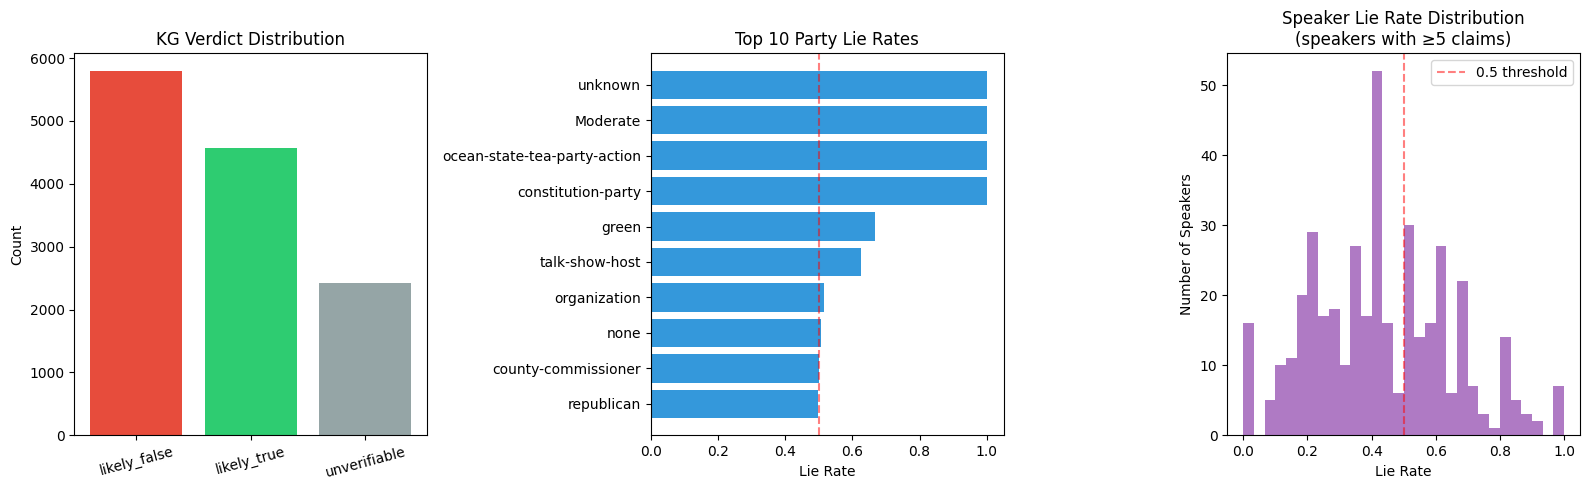

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Verdict distribution
verdict_counts = df_kg["kg_verdict"].value_counts()
colors = {"likely_false": "#e74c3c",
          "likely_true":  "#2ecc71",
          "unverifiable": "#95a5a6"}
axes[0].bar(verdict_counts.index,
            verdict_counts.values,
            color=[colors.get(v, "#3498db") for v in verdict_counts.index])
axes[0].set_title("KG Verdict Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# Plot 2 — Party lie rates
parties = sorted(party_lie_rates.items(), key=lambda x: -x[1])[:10]
pnames  = [p[0] for p in parties]
prates  = [p[1] for p in parties]
axes[1].barh(pnames[::-1], prates[::-1], color="#3498db")
axes[1].set_title("Top 10 Party Lie Rates")
axes[1].set_xlabel("Lie Rate")
axes[1].axvline(x=0.5, color="red", linestyle="--", alpha=0.5)

# Plot 3 — Speaker lie rate distribution
lie_rates = [p["lie_rate"] for p in speaker_profiles.values()
             if p["total_claims"] >= 5]
axes[2].hist(lie_rates, bins=30, color="#9b59b6", alpha=0.8)
axes[2].set_title(f"Speaker Lie Rate Distribution\n(speakers with ≥5 claims)")
axes[2].set_xlabel("Lie Rate")
axes[2].set_ylabel("Number of Speakers")
axes[2].axvline(x=0.5, color="red", linestyle="--",
                alpha=0.5, label="0.5 threshold")
axes[2].legend()

plt.tight_layout()
plt.savefig("kg_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

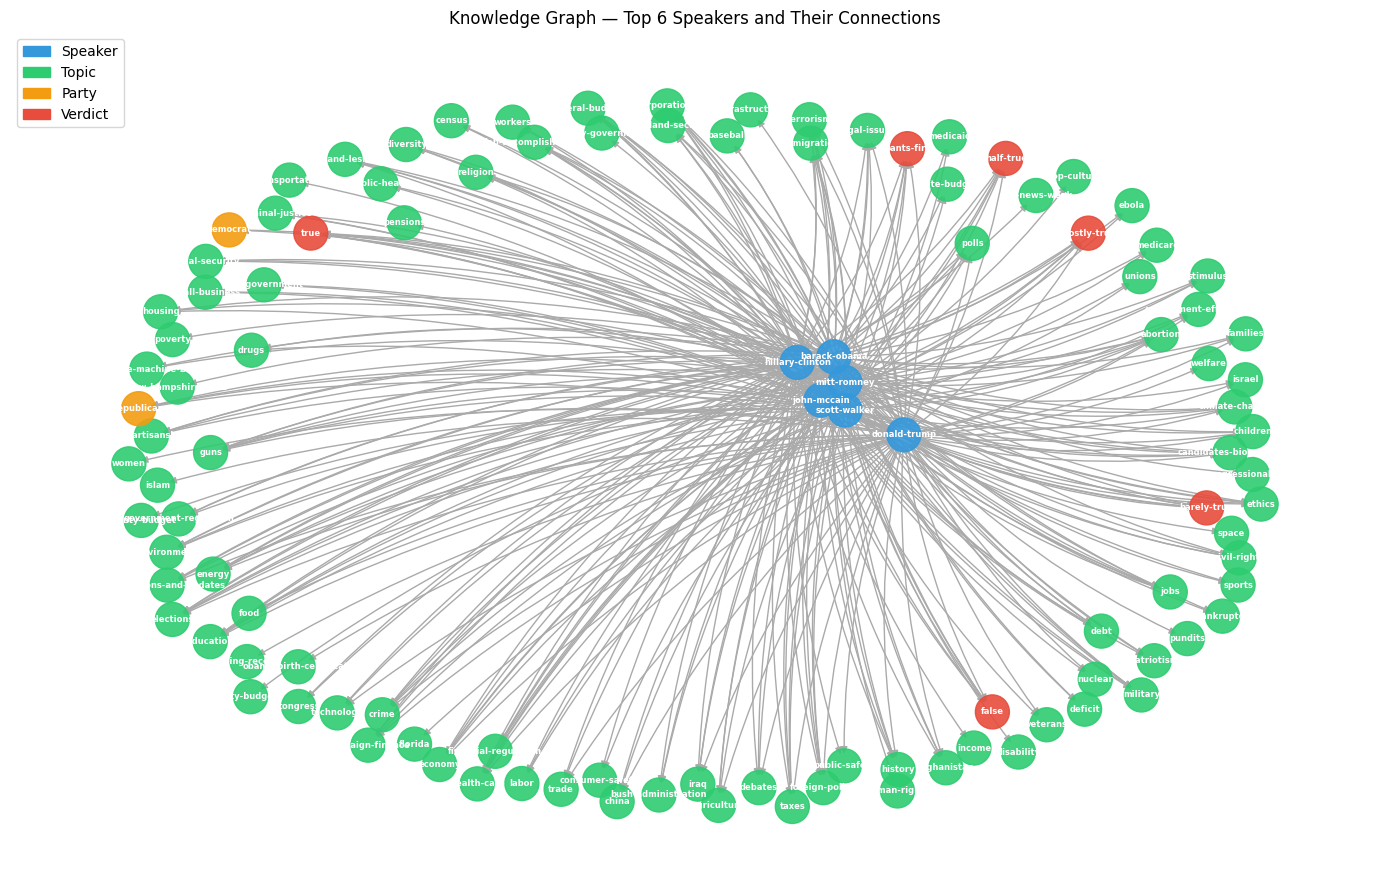

In [12]:
# Visualise a small subgraph around top speakers
top_speakers = sorted(
    speaker_profiles.items(),
    key=lambda x: -x[1]["total_claims"]
)[:6]
top_speaker_names = [s[0] for s in top_speakers]

# Build subgraph
nodes_to_show = set(top_speaker_names)
for sp in top_speaker_names:
    for neighbor in G.successors(sp):
        nodes_to_show.add(neighbor)

subgraph = G.subgraph(nodes_to_show)

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(subgraph, seed=42, k=1.5)

# Color nodes by type
node_colors = []
for node in subgraph.nodes():
    ntype = G.nodes[node].get("node_type", "")
    if ntype == "speaker":   node_colors.append("#3498db")
    elif ntype == "topic":   node_colors.append("#2ecc71")
    elif ntype == "party":   node_colors.append("#f39c12")
    elif ntype == "verdict": node_colors.append("#e74c3c")
    else:                    node_colors.append("#95a5a6")

nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors,
                       node_size=600, alpha=0.9)
nx.draw_networkx_labels(subgraph, pos, font_size=6,
                        font_color="white", font_weight="bold")
nx.draw_networkx_edges(subgraph, pos, arrows=True,
                       arrowsize=10, edge_color="#aaaaaa",
                       connectionstyle="arc3,rad=0.1")

legend_elements = [
    mpatches.Patch(color="#3498db", label="Speaker"),
    mpatches.Patch(color="#2ecc71", label="Topic"),
    mpatches.Patch(color="#f39c12", label="Party"),
    mpatches.Patch(color="#e74c3c", label="Verdict"),
]
plt.legend(handles=legend_elements, loc="upper left")
plt.title("Knowledge Graph — Top 6 Speakers and Their Connections")
plt.axis("off")
plt.tight_layout()
plt.savefig("kg_subgraph.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
with open("kg_results.json", "w", encoding="utf-8") as f:
    json.dump(kg_results, f, indent=2, ensure_ascii=False, default=str)

print(f"Saved {len(kg_results)} records to kg_results.json")
print("\nSample record:")
print(json.dumps(kg_results[0], indent=2))

Saved 12791 records to kg_results.json

Sample record:
{
  "claim_id": "2635.json",
  "raw_claim": "Says the Annies List political group supports third-trimester abortions on demand.",
  "label": "false",
  "label_binary": 0.0,
  "split": "train",
  "speaker": "dwayne-bohac",
  "party": "republican",
  "topic": "abortion",
  "speaker_lie_rate": 1.0,
  "kg_verdict": "likely_false",
  "kg_confidence": 0.65,
  "reasoning_rules": [
    "high_lie_rate_1.00",
    "speaker_has_history_on_abortion",
    "direct_kg_edge_speaker_topic"
  ]
}


In [14]:
print("=" * 50)
print("Module 3 — Knowledge Graph Complete")
print("=" * 50)
print(f"Total records:      {len(kg_results)}")
print(f"KG nodes:           {G.number_of_nodes():,}")
print(f"KG edges:           {G.number_of_edges():,}")
print(f"Unique speakers:    {len(speaker_profiles):,}")
print(f"Verdict distribution:")
for v, c in df_kg["kg_verdict"].value_counts().items():
    print(f"  {v:<20} {c:>6} ({100*c/len(df_kg):.1f}%)")
print(f"\nKG accuracy (decidable test claims): {accuracy:.4f}")
print(f"\nOutput: kg_results.json")
print(f"Next:   Module 4 — Bayesian Fusion")

Module 3 — Knowledge Graph Complete
Total records:      12791
KG nodes:           3,481
KG edges:           17,191
Unique speakers:    3,309
Verdict distribution:
  likely_false           5788 (45.3%)
  likely_true            4577 (35.8%)
  unverifiable           2426 (19.0%)

KG accuracy (decidable test claims): 0.7615

Output: kg_results.json
Next:   Module 4 — Bayesian Fusion
